In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from collections import Counter 

In [2]:
df = pd.read_csv('chatgpt_reviews_clean.csv')
print('Shape:', df.shape)
df.head()

Shape: (500, 13)


,review,rating,helpful_votes,platform,language,location,version,verified_purchase,date_clean,review_length_clean,review_clean,clean_token_count,sentiment
0,"Not satisfied, many bugs and issues.",1,80,Amazon,zh,Kenya,2.1.4,No,NaN,36,not satisfy many bug issue,5,Negative
1,Amazing quality and user-friendly interface.,5,180,Flipkart,zh,France,1.2.3,No,NaN,44,amaze quality user friendly interface,5,Positive
2,"Terrible experience, needs major improvements.",2,154,Flipkart,pt,USA,1.2.3,No,NaN,46,terrible experience need major improvement,5,Negative
3,Poor performance and not user-friendly.,1,96,Amazon,es,Qatar,2.1.4,Yes,NaN,39,poor performance not user friendly,5,Negative
4,"Not satisfied, many bugs and issues.",2,139,Website,ar,Kenya,2.1.4,No,NaN,36,not satisfy many bug issue,5,Negative


In [10]:
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)

1. Rating & Sentiment Distribution

C:\Users\yogap\AppData\Local\Temp\ipykernel_7660\1944365707.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='rating', order=sorted(df['rating'].unique()), ax=axes[0], palette='RdYlGn')
C:\Users\yogap\AppData\Local\Temp\ipykernel_7660\1944365707.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='sentiment', order=['Negative', 'Neutral', 'Positive'], ax=axes[1], palette='Set1')


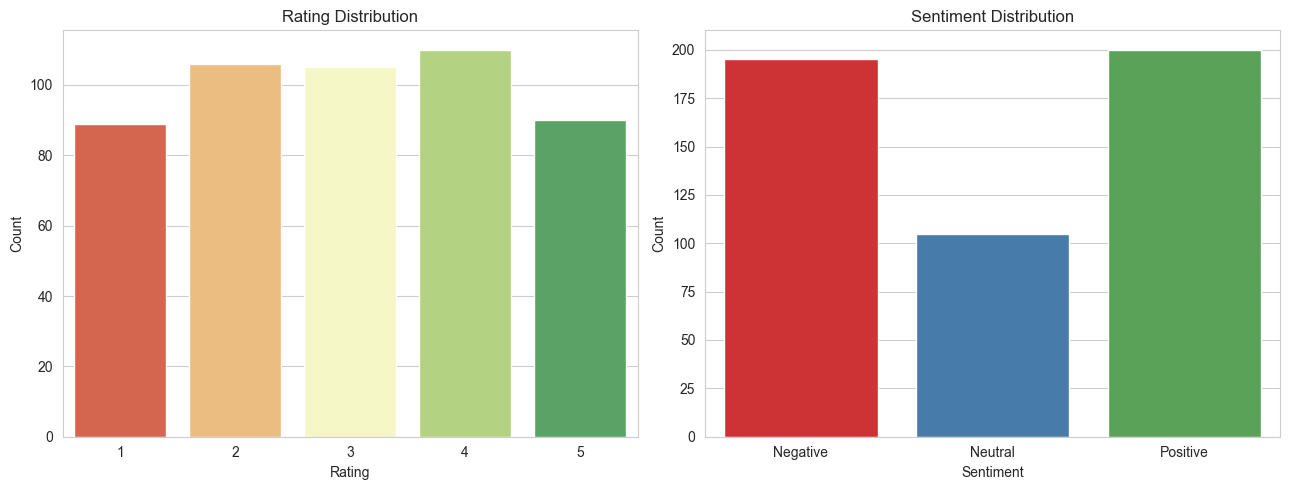

sentiment
Positive    40.0
Negative    39.0
Neutral     21.0
Name: proportion, dtype: float64


In [42]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.countplot(data=df, x='rating', order=sorted(df['rating'].unique()), ax=axes[0], palette='RdYlGn')
axes[0].set_title('Rating Distribution')
axes[0].set_xlabel('Rating')
axes[0].set_ylabel('Count')

sns.countplot(data=df, x='sentiment', order=['Negative', 'Neutral', 'Positive'], ax=axes[1], palette='Set1')
axes[1].set_title('Sentiment Distribution')
axes[1].set_xlabel('Sentiment')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

print(df['sentiment'].value_counts(normalize=True).round(3) * 100)

2. Helpful votes

C:\Users\yogap\AppData\Local\Temp\ipykernel_7660\2935711291.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='sentiment', y='helpful_votes', order=['Negative','Neutral','Positive'], ax=axes[0], palette='Set1')


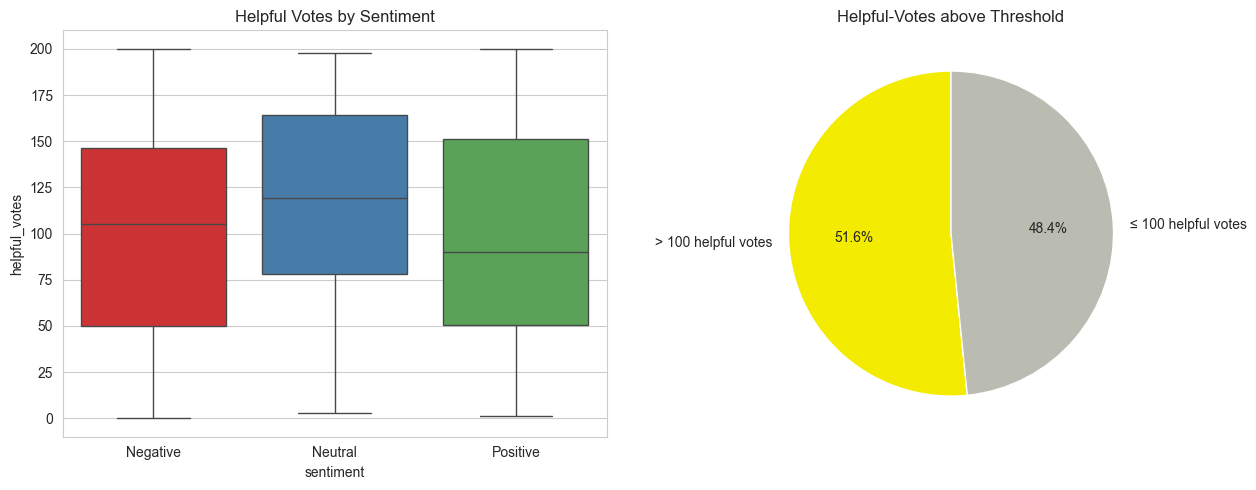

In [43]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.boxplot(data=df, x='sentiment', y='helpful_votes', order=['Negative','Neutral','Positive'], ax=axes[0], palette='Set1')
axes[0].set_title('Helpful Votes by Sentiment')

THRESHOLD = 100

above = (df['helpful_votes'] > THRESHOLD).sum()
below = (df['helpful_votes'] <= THRESHOLD).sum()

axes[1].pie([above, below], labels=[f'> {THRESHOLD} helpful votes', f'\u2264 {THRESHOLD} helpful votes'],
       autopct='%1.1f%%', colors=["#f3eb00", "#babcb1"], startangle=90)
axes[1].set_title("Helpful-Votes above Threshold")

plt.tight_layout()
plt.show()

3. Positive vs Negative Wordclouds

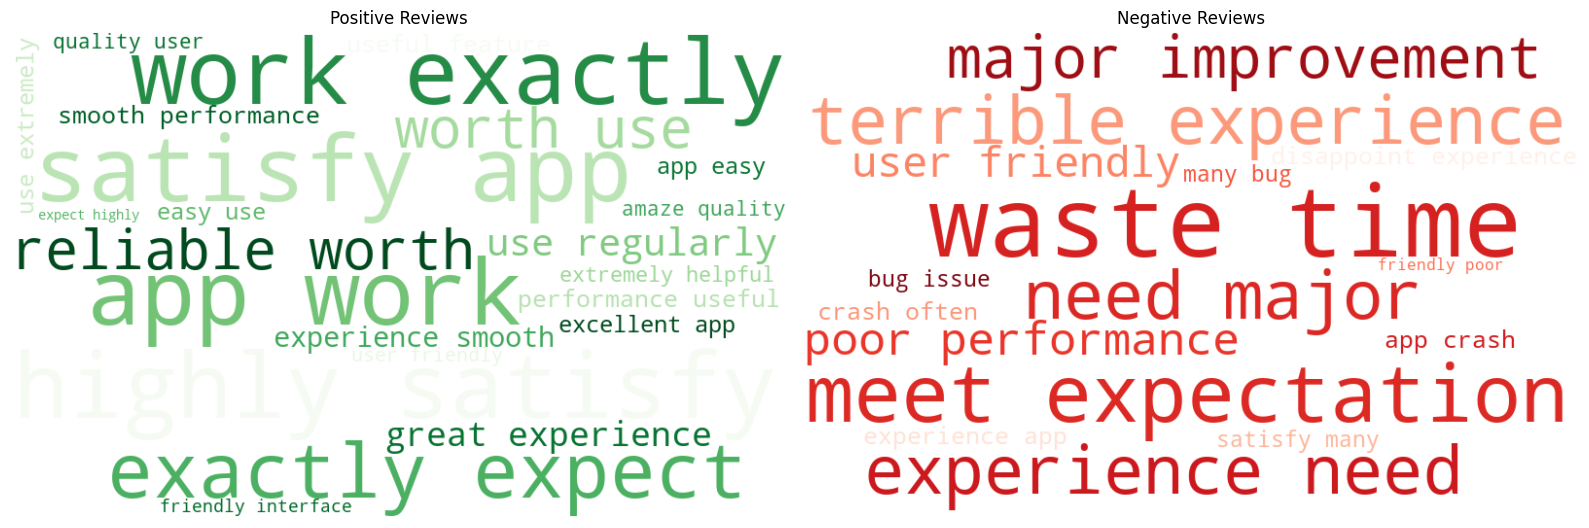

In [9]:
positive_text = ' '.join(df.loc[df['sentiment'] == 'Positive', 'review_clean'])
negative_text = ' '.join(df.loc[df['sentiment'] == 'Negative', 'review_clean'])

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

wc_pos = WordCloud(width=800, height=500, background_color='white', colormap='Greens').generate(positive_text)
axes[0].imshow(wc_pos, interpolation='bilinear'); axes[0].axis('off')
axes[0].set_title('Positive Reviews')

wc_neg = WordCloud(width=800, height=500, background_color='white', colormap='Reds').generate(negative_text)
axes[1].imshow(wc_neg, interpolation='bilinear'); axes[1].axis('off')
axes[1].set_title('Negative Reviews')

plt.tight_layout()
plt.show()

4. Rating over Time

Rows with usable dates: 142 / 500


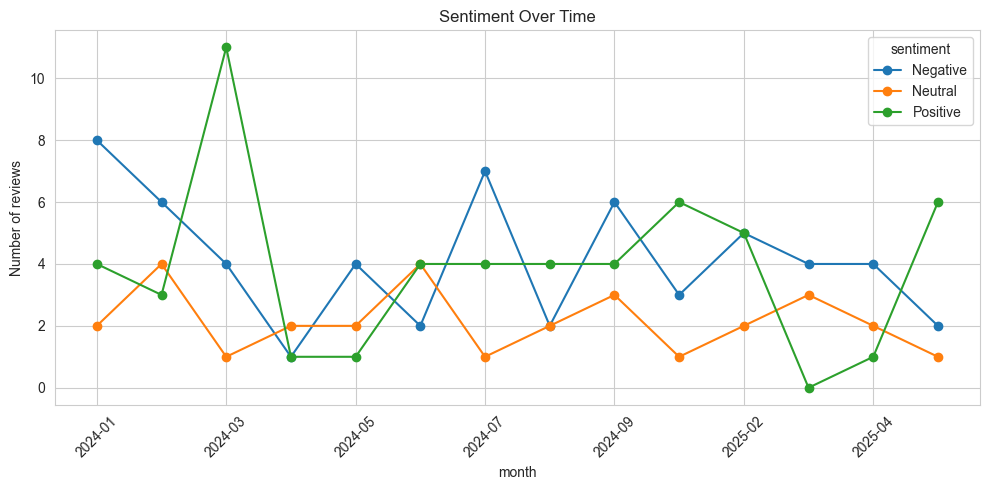

In [11]:
df['date_clean'] = pd.to_datetime(df['date_clean'])
df_time = df.dropna(subset=['date_clean']).copy()
print(f'Rows with usable dates: {len(df_time)} / {len(df)}')

df_time['month'] = df_time['date_clean'].dt.to_period('M').astype(str)
monthly_sentiment = pd.crosstab(df_time['month'], df_time['sentiment'])

monthly_sentiment.plot(kind='line', marker='o', figsize=(10, 5))
plt.title('Sentiment Over Time'.format(len(df_time)))
plt.ylabel('Number of reviews')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

5. Rating by Location

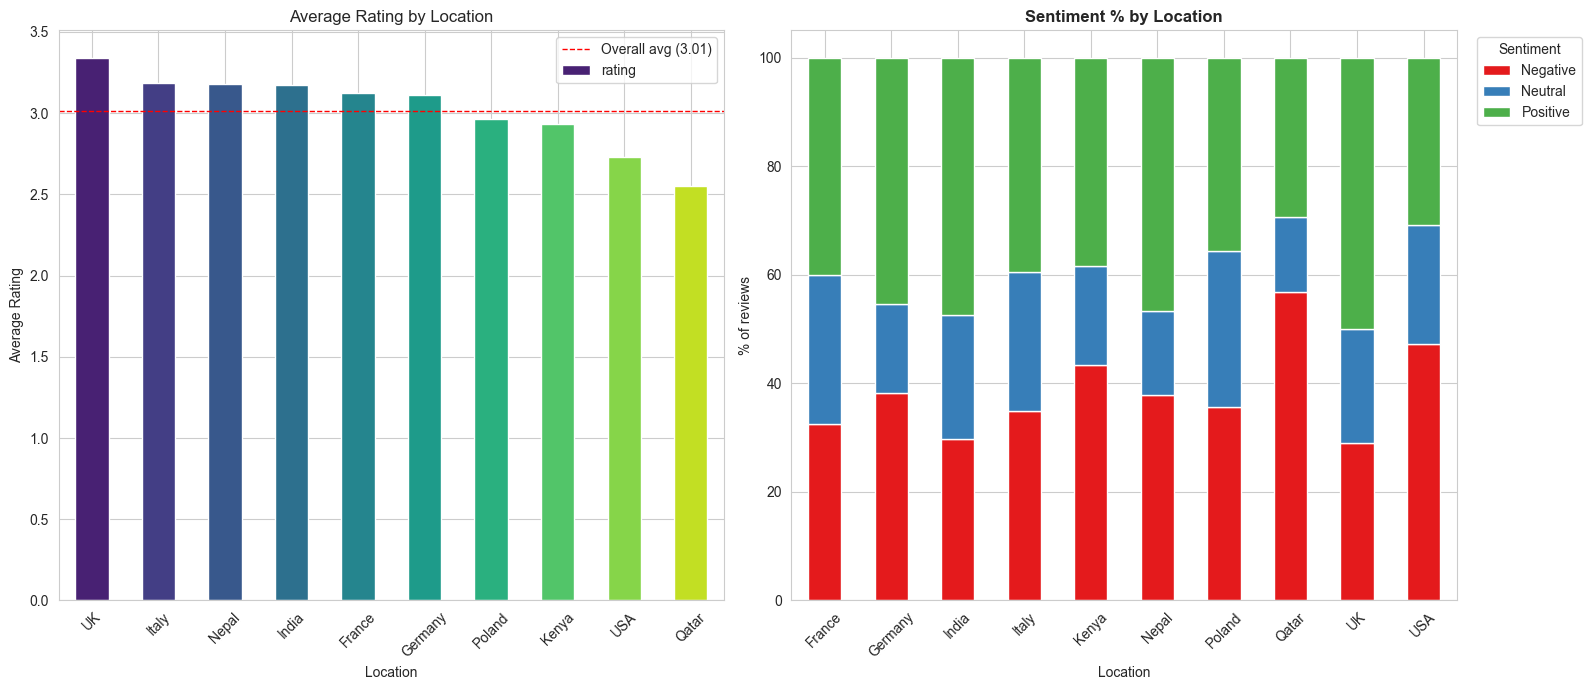

location
UK         3.342105
Italy      3.186047
Nepal      3.177778
India      3.175439
France     3.125000
Germany    3.109091
Poland     2.964286
Kenya      2.933333
USA        2.727273
Qatar      2.549020
Name: rating, dtype: float64

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
overall_mean = df["rating"].mean()

location_avg = df.groupby("location")["rating"].mean().sort_values(ascending=False)
location_avg.plot(
    kind="bar", ax=axes[0], color=sns.color_palette("viridis", len(location_avg))
)

axes[0].axhline(
    overall_mean,
    color="red",
    linestyle="--",
    linewidth=1,
    label=f"Overall avg ({overall_mean:.2f})",
)
axes[0].set(
    title="Average Rating by Location", xlabel="Location", ylabel="Average Rating"
)
axes[0].tick_params(axis="x", labelrotation=45)
axes[0].legend()

ct = (
    pd.crosstab(df["location"], df["sentiment"], normalize="index")
    .reindex(columns=["Negative", "Neutral", "Positive"], fill_value=0)
    .mul(100)
)
ct.plot(
    kind="bar",
    stacked=True,
    ax=axes[1],
    color=sns.color_palette("Set1", n_colors=3),
)
axes[1].set(
    title="Sentiment % by Location", xlabel="Location", ylabel="% of reviews"
)
axes[1].title.set_size(12)
axes[1].title.set_weight("bold")
axes[1].tick_params(axis="x", labelrotation=45)
axes[1].legend(title="Sentiment", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

location_avg

6. Reviews by Platforms

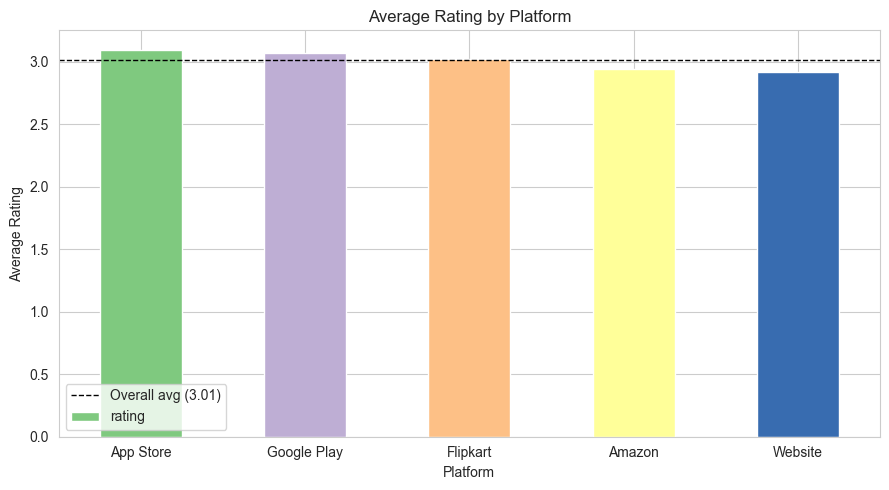

platform
App Store      3.097826
Google Play    3.068627
Flipkart       3.026549
Amazon         2.944444
Website        2.922330
Name: rating, dtype: float64

In [35]:
platform_avg = df.groupby('platform')['rating'].mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(9, 5))
platform_avg.plot(kind='bar', ax=ax, color=sns.color_palette('Accent', len(platform_avg)))
ax.set_title('Average Rating by Platform')
ax.set_xlabel('Platform'); ax.set_ylabel('Average Rating')
ax.axhline(df['rating'].mean(), color='black', linestyle='--', linewidth=1, label=f"Overall avg ({df['rating'].mean():.2f})")
ax.legend()
plt.xticks(rotation=0, ha='center')
plt.tight_layout()
plt.show()

platform_avg

7. Verified vs non-Verified Satisfaction

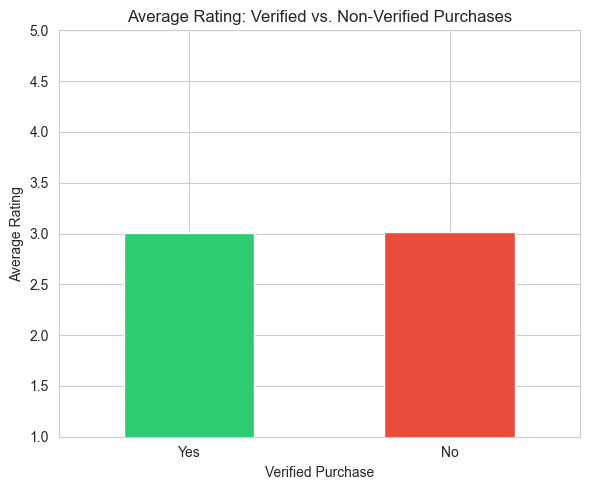

verified_purchase
Yes    3.004202
No     3.019084
Name: rating, dtype: float64

In [ ]:
verified_avg = df.groupby('verified_purchase')['rating'].mean().reindex(["Yes", "No"])
fig, ax = plt.subplots(figsize=(6, 5))
verified_avg.plot(kind='bar', ax=ax, color=['#2ecc71','#e74c3c'])
ax.set_title('Average Rating: Verified vs. Non-Verified Purchases')
ax.set_xlabel('Verified Purchase'); ax.set_ylabel('Average Rating')
ax.set_ylim(1, 5)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

verified_avg 

8. Review length by Rating

C:\Users\yogap\AppData\Local\Temp\ipykernel_7660\2189446351.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


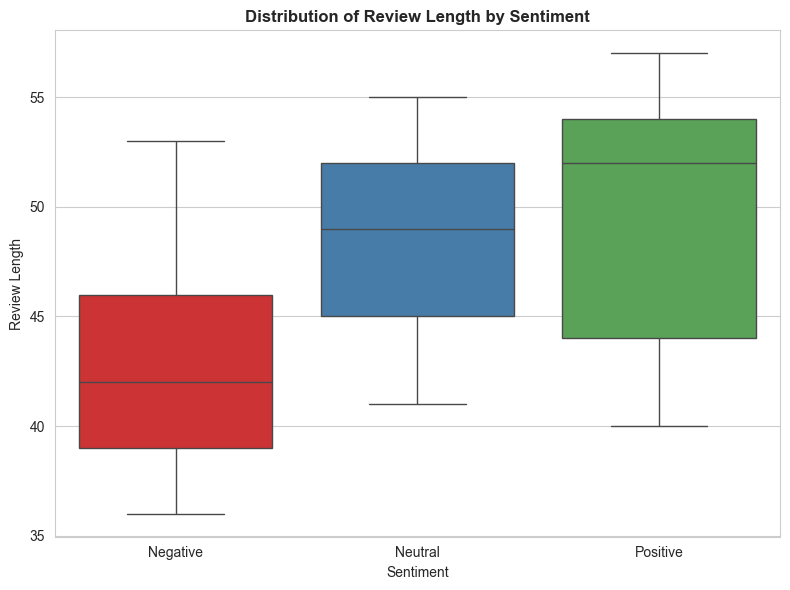

In [40]:
plt.figure(figsize=(8, 6))

sns.boxplot(
    data=df,
    x="sentiment",
    y="review_length_clean",
    order=["Negative", "Neutral", "Positive"],
    palette="Set1",
)

plt.title("Distribution of Review Length by Sentiment", fontsize=12, fontweight="bold")
plt.xlabel("Sentiment")
plt.ylabel("Review Length")
plt.tight_layout()
plt.show()

9. Most mentioned in 1-star reviews

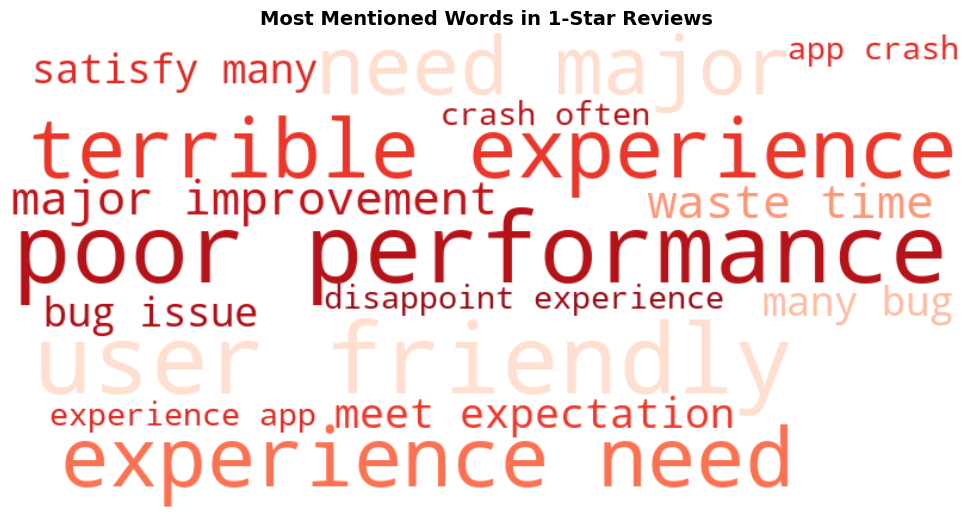

In [22]:
one_star = df[df["rating"] == 1]

text = " ".join(one_star["review_clean"].astype(str))

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color="white",
    colormap="Reds", 
).generate(text)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")  
plt.title(
    "Most Mentioned Words in 1-Star Reviews", fontsize=14, fontweight="bold"
)
plt.tight_layout(pad=0)
plt.show()

10. ChatGPT version Ratings

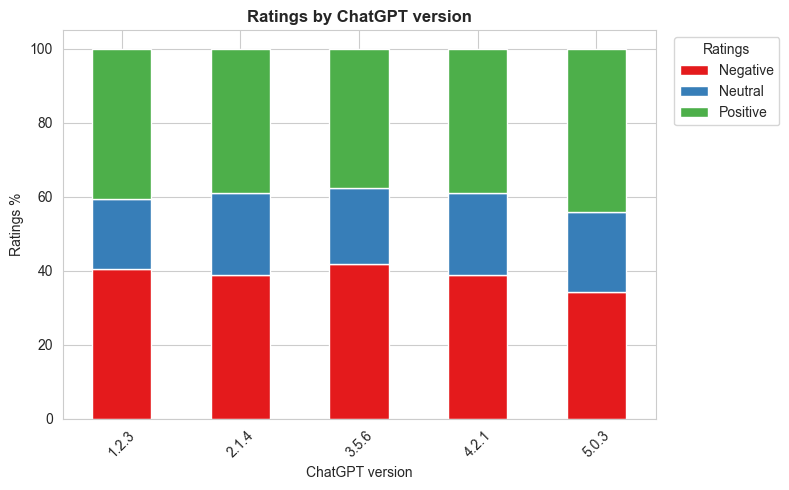

sentiment,Negative,Neutral,Positive
version,,,
1.2.3,40.566038,18.867925,40.566038
2.1.4,38.947368,22.105263,38.947368
3.5.6,41.935484,20.430108,37.634409
4.2.1,38.938053,22.123894,38.938053
5.0.3,34.408602,21.505376,44.086022


In [41]:
ct = pd.crosstab(df["version"], df["sentiment"], normalize="index") * 100
ct = ct.reindex(columns=["Negative", "Neutral", "Positive"], fill_value=0)

ct.plot(
    kind="bar",
    stacked=True,
    figsize=(8, 5),
    color=plt.get_cmap("Set1").colors[:3],
)

plt.title("Ratings by ChatGPT version", fontsize=12, fontweight="bold")
plt.ylabel("Ratings %")
plt.xlabel("ChatGPT version")
plt.legend(title="Ratings", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

ct